# Three representative 10% splits for measuring annotation time

**Goal.** Pick three disjoint batches of songs, each about **10% of the corpus**, that each look
like the corpus in miniature. An annotator works through one batch, we time it, and because the
batch is representative the measured rate extrapolates to the whole dataset — rather than
reflecting whichever songs happened to land in the pile.

**The three stratification conditions, as specified.**

| # | Condition | How it enters the design |
|---|---|---|
| 1 | **Language** | `es_ES` / `es_LATAM` — an exact stratum key |
| 2 | **M / NM label** | `is_misogynistic` — an exact stratum key |
| 3 | **Words per verse** | quintiles of each song's mean words-per-verse, cut *within* each language×label cell |

Crossing the three gives **20 strata**, and every split takes 10% of each stratum. Condition 3 is
the one that needs care: reading effort scales with text volume, it is continuous rather than
categorical, and it is heavy-tailed — so it is enforced twice, once by the quintile strata and
again by a load-balanced deal inside each stratum (§4), and then *verified* on the full
verse-level distribution with a Kolmogorov–Smirnov test (§6.3) rather than on a summary of it.

| Choice | Value |
|---|---|
| Population | `train.csv ∪ test.csv`, restricted to songs with verse annotations |
| Sampling unit | the **song** — a song's verses must stay with one annotator |
| Splits | **3**, pairwise disjoint |
| Size | **10% of songs each** (3 × 10% = 30% of the corpus) |
| Verse text | structure markers stripped, empty verses dropped |

In [19]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path("../data") if Path("../data").exists() else Path("data")
OUTPUT = DATA / "annotation_time_splits.csv"

# ---- configuration -------------------------------------------------------------
SEED = 20260914          # any reshuffle must change this deliberately, not by accident
N_SPLITS = 3             # three batches to time
TARGET_FRACTION = 0.10   # ~10% of the corpus per batch
N_WORD_BINS = 5          # quintiles of words-per-verse, cut inside each language x label cell
# --------------------------------------------------------------------------------

# categorical slots 1-3 of the reference palette; validated all-pairs for CVD
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
SPLIT_COLORS = [BLUE, ORANGE, AQUA]
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#eceae6"

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 9,
    "axes.edgecolor": "#d8d7d3", "axes.labelcolor": INK_SOFT,
    "axes.titlesize": 10, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT, "legend.frameon": False,
})
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

## 1. Join train and test into one population

In [20]:
train = pd.read_csv(DATA / "train.csv").assign(source_split="train")
test = pd.read_csv(DATA / "test.csv").assign(source_split="test")
population = pd.concat([train, test], ignore_index=True)

assert not population["song_id"].duplicated().any(), "song_id is not unique across the splits"
split_ids = set(population["song_id"])

print(f"train {len(train):,} + test {len(test):,} = {len(population):,} songs")
print(population.groupby(["language", "is_misogynistic"]).size().to_string())

train 2,303 + test 576 = 2,879 songs
language  is_misogynistic
es_ES     M                  567
          NM                 835
es_LATAM  M                  694
          NM                 783


## 2. Load the verse text and strip the meta delimiters

The verse text lives in `dataset_sin_pseudoetiquetado.csv`, one row per *annotation*, so each
verse repeats once per annotator with identical text. We drop the file's blank padding rows,
restrict to the joined population, and deduplicate to one row per verse.

In [21]:
annotations = pd.read_csv(DATA / "dataset_sin_pseudoetiquetado.csv", low_memory=False)
blank = annotations["verse_id"].isna()
annotations = annotations[~blank].copy()
annotations["song_id"] = annotations["song_id"].astype("int64")
annotations["verse_number"] = annotations["verse_number"].astype("int64")
annotations = annotations[annotations["song_id"].isin(split_ids)]

assert (annotations.groupby("verse_id")["lyrics"].nunique() <= 1).all(), \
    "verse text differs between annotators of the same verse"

verses = (
    annotations
    .drop_duplicates("verse_id")[["verse_id", "song_id", "verse_number", "lyrics"]]
    .merge(population[["song_id", "song_title", "artist_name", "language",
                       "is_misogynistic", "source_split"]], on="song_id", how="left")
    .sort_values(["song_id", "verse_number"], ignore_index=True)
)

print(f"blank padding rows dropped : {blank.sum():,}")
print(f"annotation rows in scope   : {len(annotations):,}")
print(f"unique verses              : {len(verses):,} over {verses['song_id'].nunique():,} songs")

blank padding rows dropped : 3,651
annotation rows in scope   : 84,464
unique verses              : 21,985 over 2,879 songs


### The delimiter-removal rule

Words per verse is condition 3, so the word count has to be the count of words an annotator
actually reads — structure markers are not lyrics and must not inflate it. The markers appear in
four shapes, and a naive "drop lines that are wholly `[...]`" misses three of them:

| Shape | Example | Action |
|---|---|---|
| marker alone on its line | `[Coro]`, `[Letra de "…"]` | drop the line |
| marker plus a repetition cue | `[Coro] X2` | drop the line |
| marker wrapped across two lines | `[O` … `utro: Anuel AA]` | drop both fragments |
| inaudible cue inside a real lyric | `Bandejón central [?] y un LP` | strip the cue, **keep the line** |

The last case is why the rule cleans lines rather than merely filtering them — those are genuine
lyrics with a transcription artifact in the middle.

In [22]:
BRACKET_SPAN = re.compile(r"\[[^\]]*\]")    # a complete [...] marker
OPEN_TAIL = re.compile(r"\[[^\]]*$")        # '[Estribillo: Yung Beef &'  - wraps onto the next line
CLOSE_HEAD = re.compile(r"^[^\[\]]*\]")     # 'utro: Anuel AA]'           - tail of a wrapped marker
REPEAT_CUE = re.compile(r"^[xX]\s*\d+$")
WORD = re.compile(r"\w+", re.UNICODE)


def clean_line(line):
    # Returns the line with meta delimiters removed, or None if nothing annotatable remains.
    out = CLOSE_HEAD.sub(" ", line)
    out = BRACKET_SPAN.sub(" ", out)
    out = OPEN_TAIL.sub(" ", out)
    out = re.sub(r"\s+([,.;:!?)])", r"\1", out)   # tidy the space a removal left before punctuation
    out = re.sub(r"\s{2,}", " ", out).strip(" -–—,")
    if not out or REPEAT_CUE.match(out) or not WORD.search(out):
        return None
    return out


def clean_verse(text):
    kept = (clean_line(line) for line in str(text).split("\n") if line.strip())
    return [line for line in kept if line]


for example in ["[Coro]", "[Coro] X2", "utro: Anuel AA]", "[Estribillo: Yung Beef &",
                "Bandejón central [?] y un LP", "You know"]:
    print(f"{example!r:34} -> {clean_line(example)!r}")

'[Coro]'                           -> None
'[Coro] X2'                        -> None
'utro: Anuel AA]'                  -> None
'[Estribillo: Yung Beef &'         -> None
'Bandejón central [?] y un LP'     -> 'Bandejón central y un LP'
'You know'                         -> 'You know'


In [23]:
verses["lines"] = verses["lyrics"].map(clean_verse)
verses["verse_text"] = verses["lines"].str.join("\n")
verses["n_lines"] = verses["lines"].str.len()
verses["n_words"] = verses["lines"].map(lambda ls: sum(len(WORD.findall(l)) for l in ls))
verses["n_chars"] = verses["lines"].map(lambda ls: sum(len(l) for l in ls))

residual = verses["verse_text"].str.contains(r"[\[\]]", regex=True).sum()
assert residual == 0, f"{residual} verses still contain bracket characters"

empty = verses["n_lines"] == 0
print(f"verses left empty by the cleaning: {empty.sum()} ({empty.mean():.2%}) - dropped")
print(f"content lines retained           : {verses['n_lines'].sum():,}")

verses = verses[~empty].copy()
print(f"\nannotatable verses: {len(verses):,} over {verses['song_id'].nunique():,} songs, "
      f"{verses['n_words'].sum():,} words")

verses left empty by the cleaning: 173 (0.79%) - dropped
content lines retained           : 147,822

annotatable verses: 21,812 over 2,879 songs, 1,016,479 words


## 3. Build the strata — the three conditions

Each song is reduced to one row carrying the three stratification keys.

Conditions 1 and 2 are categorical and used as-is. Condition 3 — words per verse — is continuous,
so it is cut into **quintiles**, and the cut is made **inside each language×label cell** rather
than globally. That matters: the four cells have genuinely different length profiles (Spanish
misogynistic tracks skew long, Latin-American non-misogynistic ones short), so a single global cut
would leave some cells nearly empty in the extreme bins and give those strata quotas too small to
divide across three splits. Cutting within the cell makes every one of the 20 strata equally
populated by construction, and makes each split match the population's words-per-verse
distribution *conditional on* language and label — a stronger property than matching it overall.

In [6]:
songs = (
    verses.groupby("song_id")
    .agg(n_verses=("verse_id", "size"),
         words_per_verse=("n_words", "mean"),
         total_words=("n_words", "sum"),
         total_lines=("n_lines", "sum"))
    .join(population.set_index("song_id")[["song_title", "artist_name", "language",
                                           "is_misogynistic", "source_split"]])
)

# Condition 3: quintiles of words-per-verse, cut inside each language x label cell.
# Ranking first guarantees N_WORD_BINS equally sized bins even where values tie.
cell = songs.groupby(["language", "is_misogynistic"])["words_per_verse"]
songs["words_bin"] = cell.transform(
    lambda s: pd.qcut(s.rank(method="first"), N_WORD_BINS, labels=False))

songs["stratum"] = (songs["language"] + " | " + songs["is_misogynistic"]
                    + " | wpv-" + songs["words_bin"].astype(str))

stratum_sizes = songs.groupby("stratum").size().rename("songs")
print(f"{len(stratum_sizes)} strata over {len(songs):,} songs\n")

edges = (
    songs.groupby(["language", "is_misogynistic", "words_bin"])["words_per_verse"]
    .agg(songs="size", lo="min", hi="max").round(1)
)
print("words-per-verse quintile ranges within each language x label cell:")
print(edges.to_string())

20 strata over 2,879 songs

words-per-verse quintile ranges within each language x label cell:
                                    songs    lo       hi
language is_misogynistic words_bin                      
es_ES    M               0            114 14.40    41.50
                         1            113 41.50    51.60
                         2            113 51.60    63.10
                         3            113 63.30    79.30
                         4            114 79.40   327.80
         NM              0            167 12.80    27.50
                         1            167 27.60    35.00
                         2            167 35.00    43.90
                         3            167 44.00    58.60
                         4            167 58.70   213.80
es_LATAM M               0            139  9.10    31.50
                         1            139 31.50    41.80
                         2            138 41.80    53.60
                         3            139 53.70   

### Is the design feasible?

Each split takes `round(stratum size × 10%)` songs from every stratum. Three disjoint splits are
only possible if that quota, times three, fits inside every stratum. The assertions below refuse
an over-ambitious `N_SPLITS`, `TARGET_FRACTION` or `N_WORD_BINS` *before* any sampling happens.

In [7]:
quota = (stratum_sizes * TARGET_FRACTION).round().astype(int).rename("per split")
feasibility = pd.DataFrame({
    "stratum size": stratum_sizes,
    "per split": quota,
    f"needed by {N_SPLITS}": quota * N_SPLITS,
    "slack": stratum_sizes - quota * N_SPLITS,
})

assert (quota > 0).all(), "a stratum is too small to contribute to every split"
assert (feasibility["slack"] >= 0).all(), "not enough songs to fill disjoint splits at this size"

print(feasibility.to_string())
print(f"\nsplit size: {quota.sum()} songs ({quota.sum() / len(songs):.2%} of the corpus)")
print(f"{N_SPLITS} splits cover {quota.sum() * N_SPLITS:,} songs "
      f"({quota.sum() * N_SPLITS / len(songs):.1%}); "
      f"{len(songs) - quota.sum() * N_SPLITS:,} songs left unassigned")

                       stratum size  per split  needed by 3  slack
stratum                                                           
es_ES | M | wpv-0               114         11           33     81
es_ES | M | wpv-1               113         11           33     80
es_ES | M | wpv-2               113         11           33     80
es_ES | M | wpv-3               113         11           33     80
es_ES | M | wpv-4               114         11           33     81
es_ES | NM | wpv-0              167         17           51    116
es_ES | NM | wpv-1              167         17           51    116
es_ES | NM | wpv-2              167         17           51    116
es_ES | NM | wpv-3              167         17           51    116
es_ES | NM | wpv-4              167         17           51    116
es_LATAM | M | wpv-0            139         14           42     97
es_LATAM | M | wpv-1            139         14           42     97
es_LATAM | M | wpv-2            138         14           42   

## 4. Allocate the three splits

A plain random deal inside each stratum is not good enough for condition 3. Words per verse is
heavy-tailed even *within* a quintile, so a random draw can pile the long songs into one batch —
and with only three batches there is nowhere for that imbalance to average out. The allocation is
therefore three steps, applied inside every stratum:

1. **Sort** the stratum by words per verse.
2. **Systematically sample** `3 × quota` songs at even spacing across that whole sorted range,
   with a random offset. Spanning the full range matters: taking a block off the front would
   silently exclude the longest songs in the bin from all three splits.
3. **Deal by longest-first load balancing.** Walk the sampled songs from longest to shortest — by
   *total words*, which is what a batch actually costs an annotator — and give each to whichever
   split currently carries the lightest load, subject to that split's per-stratum quota. This is
   the standard LPT heuristic, and it is what keeps the three batches level.

Disjointness is structural: every song is sampled at most once and assigned exactly once.

In [8]:
rng = np.random.default_rng(SEED)
assignment = {}

for stratum, members in songs.groupby("stratum"):
    members = members.sort_values("words_per_verse")
    ids = members.index.to_numpy().copy()       # pandas hands back a read-only view
    n = len(ids)
    take = quota[stratum] * N_SPLITS

    # Step 2 - systematic sample spanning the full range, random offset within one step.
    step = n / take
    positions = np.clip(np.floor((np.arange(take) + rng.random()) * step).astype(int), 0, n - 1)
    assert len(np.unique(positions)) == take, f"{stratum}: systematic sample collided"
    sampled = ids[positions]

    # Step 3 - longest-processing-time deal onto the least-loaded split.
    weight = members["total_words"].to_dict()
    load = np.zeros(N_SPLITS)
    filled = np.zeros(N_SPLITS, dtype=int)
    for song_id in sorted(sampled, key=lambda i: -weight[i]):
        open_splits = np.where(filled < quota[stratum])[0]
        # the tiny jitter breaks ties without making the result seed-dependent in any other way
        choice = open_splits[np.argmin(load[open_splits] + rng.random(len(open_splits)) * 1e-9)]
        assignment[song_id] = choice + 1
        load[choice] += weight[song_id]
        filled[choice] += 1

songs["annotation_split"] = songs.index.map(assignment)
assigned = songs[songs["annotation_split"].notna()].copy()
assigned["annotation_split"] = assigned["annotation_split"].astype(int)

print(f"assigned {len(assigned):,} songs to {N_SPLITS} splits; "
      f"{len(songs) - len(assigned):,} songs left unassigned\n")
print(assigned["annotation_split"].value_counts().sort_index().to_string())

assigned 870 songs to 3 splits; 2,009 songs left unassigned

annotation_split
1    290
2    290
3    290


### Verification

Five things must hold, and each is asserted rather than eyeballed.

In [9]:
sizes = assigned.groupby("annotation_split").size()
assert sizes.nunique() == 1, f"splits differ in size: {sizes.to_dict()}"
print(f"1. every split has exactly {sizes.iloc[0]} songs          : ok")

members = {n: set(g.index) for n, g in assigned.groupby("annotation_split")}
overlaps = [(a, b, len(members[a] & members[b]))
            for a in members for b in members if a < b and members[a] & members[b]]
assert not overlaps, f"splits overlap: {overlaps[:5]}"
print(f"2. all {N_SPLITS * (N_SPLITS - 1) // 2} split pairs are disjoint         : ok")

assert set(assigned.index) <= split_ids, "a selected song is not in train or test"
print("3. every selected song is in train or test    : ok")

assert set(assigned.index) <= set(verses["song_id"]), "a selected song has no annotatable verses"
print("4. every selected song has verse text         : ok")

per_stratum = assigned.groupby(["stratum", "annotation_split"]).size().unstack(fill_value=0)
assert per_stratum.eq(quota, axis=0).all().all(), "a stratum quota was not met exactly"
print(f"5. every split meets its quota in all {len(stratum_sizes)} strata : ok")

share = sizes.iloc[0] / len(songs)
print(f"\neach split is {sizes.iloc[0]} songs = {share:.2%} of the corpus")

1. every split has exactly 290 songs          : ok
2. all 3 split pairs are disjoint         : ok
3. every selected song is in train or test    : ok
4. every selected song has verse text         : ok
5. every split meets its quota in all 20 strata : ok

each split is 290 songs = 10.07% of the corpus


## 5. Is each split representative?

The assertions prove the splits are *valid*; they do not prove they are *representative*. This
section tests the three conditions in turn, plus the two quantities that actually drive how long a
batch takes and that are deliberately **not** stratified on — verses per song and words per song.
Those two are the real test: they land close to the population only if the stratification captured
what matters, so they are measured rather than assumed.

In [10]:
def profile(frame):
    return pd.Series({
        "songs": len(frame),
        "% es_ES": (frame["language"] == "es_ES").mean() * 100,
        "% M": (frame["is_misogynistic"] == "M").mean() * 100,
        "words/verse (mean)": frame["words_per_verse"].mean(),
        "words/verse (median)": frame["words_per_verse"].median(),
        "verses/song": frame["n_verses"].mean(),
        "words/song": frame["total_words"].mean(),
    })

balance = pd.DataFrame({f"split {n}": profile(g) for n, g in assigned.groupby("annotation_split")}).T
balance.loc["POPULATION"] = profile(songs)
print(balance.to_string())

reference = balance.loc["POPULATION"]
deviation = (balance.drop(index="POPULATION") - reference).abs()
print("\nWorst deviation from the population, across the three splits:")
for column in ["% es_ES", "% M", "words/verse (mean)", "words/verse (median)",
               "verses/song", "words/song"]:
    worst = deviation[column].max()
    print(f"  {column:<22} {worst:8.2f}   ({worst / reference[column]:6.2%} of the population value)")

              songs  % es_ES   % M  words/verse (mean)  words/verse (median)  verses/song  words/song
split 1      290.00    48.28 43.10               48.90                 41.92         7.57      352.34
split 2      290.00    48.28 43.10               47.05                 41.00         7.67      353.14
split 3      290.00    48.28 43.10               49.01                 41.25         7.59      352.91
POPULATION 2,879.00    48.70 43.80               50.99                 41.60         7.58      353.07

Worst deviation from the population, across the three splits:
  % es_ES                    0.42   ( 0.87% of the population value)
  % M                        0.70   ( 1.59% of the population value)
  words/verse (mean)         3.94   ( 7.73% of the population value)
  words/verse (median)       0.60   ( 1.44% of the population value)
  verses/song                0.10   ( 1.27% of the population value)
  words/song                 0.73   ( 0.21% of the population value)


### 5.1 Conditions 1 and 2 — language and label

Because both are exact stratum keys and every quota is met exactly, the marginal *and joint*
distributions are reproduced to rounding. The table below is the joint one, which is the stronger
claim: it is not merely that each split has the right share of `es_ES` and the right share of `M`,
but the right share of every language×label combination.

In [11]:
key = (assigned["language"] + " x " + assigned["is_misogynistic"]).rename("cell")
cells = pd.crosstab(key, assigned["annotation_split"], normalize="columns") * 100
cells["POPULATION"] = (songs["language"] + " x " + songs["is_misogynistic"]).value_counts(
    normalize=True).mul(100).reindex(cells.index)
cells.columns = [f"split {c}" if isinstance(c, (int, np.integer)) else c for c in cells.columns]

worst_cell = (cells.drop(columns="POPULATION")
              .sub(cells["POPULATION"], axis=0).abs().max().max())
print("share of each language x label cell (%):\n")
print(cells.to_string())
print(f"\nworst deviation from the population on any cell, any split: "
      f"{worst_cell:.2f} percentage points")

share of each language x label cell (%):

               split 1  split 2  split 3  POPULATION
cell                                                
es_ES x M        18.97    18.97    18.97       19.69
es_ES x NM       29.31    29.31    29.31       29.00
es_LATAM x M     24.14    24.14    24.14       24.11
es_LATAM x NM    27.59    27.59    27.59       27.20

worst deviation from the population on any cell, any split: 0.73 percentage points


### 5.2 Condition 3 — the words-per-verse distribution

Two batches can share a mean and a quintile profile and still differ in the tails, so the summary
statistics above are not sufficient. A two-sample **Kolmogorov–Smirnov** statistic compares each
split's *verse-level* words distribution against the population's in full — every quantile, not a
summary of them. This is the strongest single check that condition 3 was honoured.

In [12]:
def ks_statistic(a, b):
    a, b = np.sort(np.asarray(a)), np.sort(np.asarray(b))
    grid = np.concatenate([a, b])
    return np.max(np.abs(np.searchsorted(a, grid, side="right") / len(a)
                         - np.searchsorted(b, grid, side="right") / len(b)))


verses = verses.merge(assigned[["annotation_split"]], left_on="song_id",
                      right_index=True, how="left")
population_words = verses["n_words"].to_numpy()
in_split = verses.dropna(subset=["annotation_split"])

rows = []
for split_number, group in in_split.groupby("annotation_split"):
    sample = group["n_words"].to_numpy()
    statistic = ks_statistic(sample, population_words)
    critical = 1.36 * np.sqrt(1 / len(sample) + 1 / len(population_words))  # two-sided, alpha = 5%
    rows.append({"split": int(split_number), "verses": len(sample),
                 "median": np.median(sample), "p90": np.percentile(sample, 90),
                 "KS D": statistic, "critical D (5%)": critical,
                 "matches": "yes" if statistic < critical else "NO"})

ks = pd.DataFrame(rows).set_index("split")
KS_CRITICAL = ks["critical D (5%)"].max()
ks.loc["POPULATION"] = {"verses": len(population_words),
                        "median": np.median(population_words),
                        "p90": np.percentile(population_words, 90),
                        "KS D": np.nan, "critical D (5%)": np.nan, "matches": ""}
print(ks.to_string())
matched = (ks["matches"] == "yes").sum()
print(f"\nsplits whose words-per-verse distribution is indistinguishable from the population "
      f"at the 5% level: {matched} / {N_SPLITS}")

            verses  median   p90  KS D  critical D (5%) matches
split                                                          
1             2195   36.00 91.00  0.01             0.03     yes
2             2225   37.00 87.00  0.01             0.03     yes
3             2201   37.00 87.00  0.02             0.03     yes
POPULATION   21812   36.00 89.00   NaN              NaN        

splits whose words-per-verse distribution is indistinguishable from the population at the 5% level: 3 / 3


### 5.3 What 10% means in verses and words, not just songs

The quota is expressed in songs because the song is the sampling unit. Annotation effort, though,
is spent per verse and per word — so the share of *those* is what the timing extrapolation
actually multiplies back up. They are not forced to 10% anywhere in the design; they land there
because the stratification and the load-balanced deal put them there.

In [13]:
coverage = in_split.groupby("annotation_split").agg(
    songs=("song_id", "nunique"), verses=("verse_id", "size"), words=("n_words", "sum"))
coverage["% of songs"] = coverage["songs"] / len(songs) * 100
coverage["% of verses"] = coverage["verses"] / len(verses) * 100
coverage["% of words"] = coverage["words"] / verses["n_words"].sum() * 100
coverage.index = [f"split {int(i)}" for i in coverage.index]
coverage.loc["TOTAL"] = coverage.sum()
print(coverage.to_string())

spread = coverage.drop(index="TOTAL")
print(f"\nthe three batches differ by {spread['words'].max() - spread['words'].min():,} words "
      f"({(spread['words'].max() / spread['words'].min() - 1):.2%}) and "
      f"{spread['verses'].max() - spread['verses'].min():,} verses "
      f"({(spread['verses'].max() / spread['verses'].min() - 1):.2%})")

         songs   verses      words  % of songs  % of verses  % of words
split 1 290.00 2,195.00 102,178.00       10.07        10.06       10.05
split 2 290.00 2,225.00 102,412.00       10.07        10.20       10.08
split 3 290.00 2,201.00 102,344.00       10.07        10.09       10.07
TOTAL   870.00 6,621.00 306,934.00       30.22        30.35       30.20

the three batches differ by 234.0 words (0.23%) and 30.0 verses (1.37%)


### 5.4 The one measure that cannot be levelled

Every measure lands within a couple of percent except the *mean* words per verse, where all three
splits sit **below** the population. That is not an imbalance between the batches — they are low
together and by almost the same amount. It is a property of the population: its mean is inflated
by four songs that consist of one enormous unbroken verse of 1,765–2,359 words. Each is
indivisible, four of them cannot be spread evenly over three batches in any case, and a 30% sample
drew none of them. Against the outlier-trimmed population mean the three splits land within a
couple of percent, which is the honest comparison.

The practical consequence is the opposite of a problem: no annotator is handed a 2,000-word wall
of text, so no one of the three timings is distorted by one. The corollary is that extrapolating
from these batches will slightly *under*-count the handful of extreme songs in the full corpus.
Judge balance on the median, on the verse-level distribution in §5.2, and on words per song.

In [14]:
EXTREME = 1500   # words in one verse; the songs above this are what inflate the population mean

outliers = songs.nlargest(5, "words_per_verse")[
    ["song_title", "artist_name", "n_verses", "words_per_verse", "annotation_split"]]
shown = outliers.assign(
    song_title=outliers["song_title"].str.slice(0, 36),
    artist_name=outliers["artist_name"].str.slice(0, 24) + "…",
    annotation_split=outliers["annotation_split"].map(
        lambda v: "unassigned" if pd.isna(v) else f"split {int(v)}"))
print("The songs that inflate the POPULATION mean (multi-artist credits truncated):\n")
print(shown.to_string(max_colwidth=38))

extreme = songs[songs["words_per_verse"] > EXTREME]
print(f"\nsongs whose single verse exceeds {EXTREME:,} words: {len(extreme)}, "
      f"of which {int(extreme['annotation_split'].notna().sum())} reached a batch")

trimmed = songs.loc[songs["words_per_verse"] <= EXTREME, "words_per_verse"].mean()
print(f"\npopulation mean words/verse       : {songs['words_per_verse'].mean():.2f}")
print(f"…excluding those {len(extreme)} extreme songs : {trimmed:.2f}")
print(f"population median words/verse     : {songs['words_per_verse'].median():.2f}")

print("\nEach split's mean words/verse, against both references:")
for split_number, group in assigned.groupby("annotation_split"):
    mean = group["words_per_verse"].mean()
    print(f"  split {split_number}: {mean:6.2f}   vs population "
          f"{mean / reference['words/verse (mean)'] - 1:+7.2%}"
          f"   vs trimmed population {mean / trimmed - 1:+7.2%}")

biggest = assigned.nlargest(3, "words_per_verse")[
    ["song_title", "n_verses", "words_per_verse", "annotation_split"]]
print("\nThe longest-per-verse songs that did reach a batch:")
print(biggest.assign(song_title=biggest["song_title"].str.slice(0, 36)).to_string(max_colwidth=38))

The songs that inflate the POPULATION mean (multi-artist credits truncated):

                                   song_title                artist_name  n_verses  words_per_verse annotation_split
song_id                                                                                                             
3461840                 Viajo Sin Ver (Remix)  Jon Z (Ft. Almighty, De …         1         2,359.00       unassigned
7895520                Descansa en Paz Yeruza  Jonna Torres, Jota River…         1         1,988.00       unassigned
6828082  Mi alma está asombrada, mi Dios Crea   Ricardo Claure Peñaloza…         1         1,812.00       unassigned
2456096                           Alerta Roja  Daddy Yankee (Ft. Alexio…         1         1,765.00       unassigned
2919464                       Círculo Vicioso                   Granuja…         1           484.00          split 3

songs whose single verse exceeds 1,500 words: 4, of which 0 reached a batch

population mean words/ver

### 5.5 The evidence in three pictures

**Left** — what condition 3 is about: the population's words-per-verse distribution, strongly
right-skewed, which is why it needed stratifying at all. **Middle** — the KS test of §5.2 drawn.
Plotting the three ECDFs on top of the population's would show four indistinguishable curves, so
instead each split's ECDF is shown as its *gap* from the population's, with the 5% critical band
shaded: a curve that stays inside the band is a split whose distribution cannot be told apart from
the corpus. **Right** — every balanced measure at once, as a deviation from the population; the
vertical rule is the population and each dot is one split.

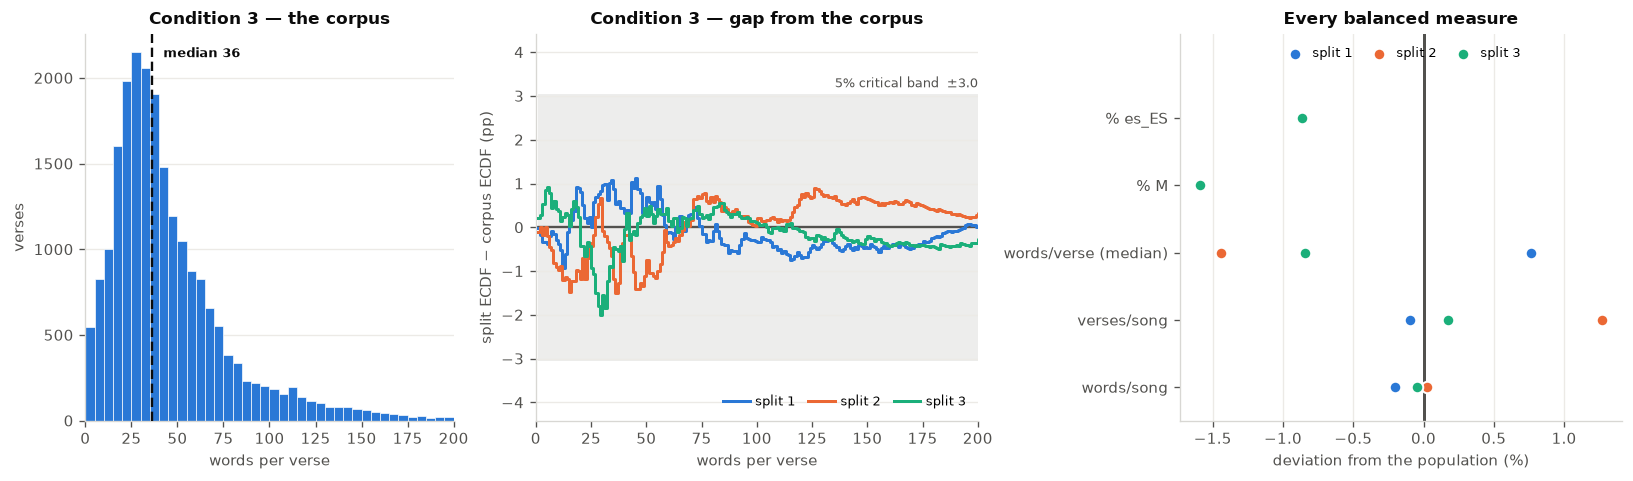

In [15]:
fig, (ax_dist, ax_gap, ax_dev) = plt.subplots(
    1, 3, figsize=(13.5, 3.9), constrained_layout=True,
    gridspec_kw={"width_ratios": [1.0, 1.2, 1.2]})

# -- left: the population's words-per-verse distribution (one series, so no legend) -------------
ax_dist.hist(population_words, bins=np.arange(0, 205, 5), color=BLUE,
             edgecolor="white", linewidth=0.4)
median_words = np.median(population_words)
ax_dist.axvline(median_words, color=INK, linewidth=1.4, linestyle=(0, (4, 2)), zorder=4)
ax_dist.annotate(f"median {median_words:.0f}", (median_words, ax_dist.get_ylim()[1] * 0.94),
                 xytext=(7, 0), textcoords="offset points", color=INK, fontsize=8,
                 fontweight="bold")
ax_dist.set_title("Condition 3 \u2014 the corpus")
ax_dist.set_xlabel("words per verse")
ax_dist.set_ylabel("verses")
ax_dist.set_xlim(0, 200)
ax_dist.grid(axis="y")
ax_dist.set_axisbelow(True)

# -- middle: each split's ECDF minus the population's, against the 5% KS band -------------------
sorted_population = np.sort(population_words)
grid = np.unique(sorted_population)
population_ecdf = np.searchsorted(sorted_population, grid, side="right") / len(sorted_population)

ax_gap.fill_between(grid, -KS_CRITICAL * 100, KS_CRITICAL * 100,
                    color=INK_SOFT, alpha=0.10, linewidth=0, zorder=0)
ax_gap.axhline(0, color=INK_SOFT, linewidth=1.4, zorder=1)
for (split_number, group), color in zip(in_split.groupby("annotation_split"), SPLIT_COLORS):
    sample = np.sort(group["n_words"].to_numpy())
    gap = np.searchsorted(sample, grid, side="right") / len(sample) - population_ecdf
    ax_gap.step(grid, gap * 100, where="post", color=color, linewidth=1.8, zorder=3,
                label=f"split {int(split_number)}")
ax_gap.annotate(f"5% critical band  \u00b1{KS_CRITICAL * 100:.1f}", (200, KS_CRITICAL * 100),
                xytext=(0, 4), textcoords="offset points", color=INK_SOFT, fontsize=8, ha="right")
ax_gap.set_title("Condition 3 \u2014 gap from the corpus")
ax_gap.set_xlabel("words per verse")
ax_gap.set_ylabel("split ECDF \u2212 corpus ECDF (pp)")
ax_gap.set_xlim(0, 200)
ax_gap.set_ylim(-KS_CRITICAL * 145, KS_CRITICAL * 145)
ax_gap.grid(axis="y")
ax_gap.set_axisbelow(True)
ax_gap.legend(loc="lower right", ncol=3, fontsize=8, handletextpad=0.4, columnspacing=1.0)

# -- right: every balanced measure, as a deviation from the population --------------------------
metrics = ["% es_ES", "% M", "words/verse (median)", "verses/song", "words/song"]
for index, metric in enumerate(metrics):
    relative = (balance.drop(index="POPULATION")[metric] / reference[metric] - 1) * 100
    for offset, (value, color) in enumerate(zip(relative, SPLIT_COLORS)):
        ax_dev.scatter(value, index, s=48, color=color, zorder=3,
                       edgecolor="white", linewidth=1.2,
                       label=f"split {offset + 1}" if index == 0 else None)
ax_dev.axvline(0, color=INK_SOFT, linewidth=1.8, zorder=2)
ax_dev.set_yticks(np.arange(len(metrics)))
ax_dev.set_yticklabels(metrics)
ax_dev.set_xlabel("deviation from the population (%)")
ax_dev.set_title("Every balanced measure")
ax_dev.grid(axis="x")
ax_dev.set_axisbelow(True)
ax_dev.invert_yaxis()
ax_dev.set_ylim(len(metrics) - 0.5, -1.25)          # reserve a blank row for the legend
ax_dev.legend(loc="upper center", ncol=3, fontsize=8, handletextpad=0.3, columnspacing=1.0)

plt.show()

## 6. Write the CSV

One row per verse to be annotated, carrying the cleaned text alongside the identifiers an
annotation tool needs and the song-level metadata the timing analysis will group by.

In [16]:
output = (
    in_split
    .assign(annotation_split=lambda d: d["annotation_split"].astype(int))
    .loc[:, ["annotation_split", "song_id", "song_title", "artist_name", "language",
             "is_misogynistic", "source_split", "verse_id", "verse_number",
             "verse_text", "n_lines", "n_words", "n_chars"]]
    .sort_values(["annotation_split", "song_id", "verse_number"], ignore_index=True)
)

assert output["verse_id"].is_unique, "a verse appears more than once"
assert output["verse_text"].str.strip().ne("").all(), "an empty verse survived into the output"
assert not output["verse_text"].str.contains(r"[\[\]]", regex=True).any(), "a delimiter survived"
assert set(output["song_id"]) <= split_ids, "a song outside train/test reached the output"
assert output["annotation_split"].nunique() == N_SPLITS, "wrong number of splits in the output"
assert output.groupby("song_id")["annotation_split"].nunique().eq(1).all(), \
    "a song is spread across more than one split"

output.to_csv(OUTPUT, index=False)
print(f"wrote {OUTPUT}  -  {len(output):,} rows, {output['song_id'].nunique():,} songs\n")
print(output.groupby("annotation_split").agg(
    songs=("song_id", "nunique"), verses=("verse_id", "size"),
    words=("n_words", "sum")).to_string())

wrote ../data/annotation_time_splits.csv  -  6,621 rows, 870 songs

                  songs  verses   words
annotation_split                       
1                   290    2195  102178
2                   290    2225  102412
3                   290    2201  102344


In [17]:
print(output.head(4).to_string(max_colwidth=40))
print("\n--- one verse as it will reach the annotator ---")
sample = output.iloc[1]
print(f"{sample['song_title']} — {sample['artist_name']} (verse {sample['verse_number']})\n")
print(sample["verse_text"][:600])

   annotation_split  song_id                 song_title           artist_name language is_misogynistic source_split   verse_id  verse_number                               verse_text  n_lines  n_words  n_chars
0                 1   172768  A las Cosas por Su Nombre  Violadores del Verso    es_ES               M        train  172768__1             1                      5 años más tarde...        1        4       19
1                 1   172768  A las Cosas por Su Nombre  Violadores del Verso    es_ES               M        train  172768__2             2  Le quité las telarañas al micro y lo...       12      105      531
2                 1   172768  A las Cosas por Su Nombre  Violadores del Verso    es_ES               M        train  172768__3             3  Me siento solo y con pena\nAunque si...       17      151      755
3                 1   172768  A las Cosas por Su Nombre  Violadores del Verso    es_ES               M        train  172768__4             4  No intentéis innovar c

## 7. Summary

In [18]:
per_split = output.groupby("annotation_split").agg(
    songs=("song_id", "nunique"), verses=("verse_id", "size"), words=("n_words", "sum"))

print("=" * 78)
print(f"{N_SPLITS} disjoint, representative ~{TARGET_FRACTION:.0%} splits  ->  {OUTPUT.name}")
print("=" * 78)
print(f"  population     : {len(songs):,} songs, {len(verses):,} annotatable verses, "
      f"{verses['n_words'].sum():,} words")
print(f"  per split      : {per_split['songs'].iloc[0]} songs "
      f"({per_split['songs'].iloc[0] / len(songs):.2%} of songs), "
      f"{per_split['verses'].min():,}-{per_split['verses'].max():,} verses "
      f"({per_split['verses'].mean() / len(verses):.2%} of verses), "
      f"{per_split['words'].mean():,.0f} words "
      f"({per_split['words'].mean() / verses['n_words'].sum():.2%} of words)")
print(f"  coverage       : {output['song_id'].nunique():,} songs "
      f"({output['song_id'].nunique() / len(songs):.1%}); "
      f"{len(songs) - output['song_id'].nunique():,} songs held back")
print(f"  disjoint       : verified for all {N_SPLITS * (N_SPLITS - 1) // 2} split pairs")
print(f"  seed           : {SEED}")
print()
print(f"  Stratified on the three specified conditions ({len(stratum_sizes)} strata):")
print(f"    1. language                  exact key   -> worst cell drift {worst_cell:.2f} pp")
print(f"    2. M / NM label              exact key   -> worst cell drift {worst_cell:.2f} pp")
print(f"    3. words per verse           quintiles within each language x label cell")
print(f"                                 -> KS vs population: {matched}/{N_SPLITS} splits match at 5%")
print()
print("  Balance vs the population (worst of the three splits):")
for column in ["% es_ES", "% M", "words/verse (median)", "verses/song", "words/song"]:
    print(f"    {column:<22} {deviation[column].max() / reference[column]:6.2%}")
print(f"    {'words/verse (mean)':<22} "
      f"{deviation['words/verse (mean)'].max() / reference['words/verse (mean)']:6.2%}"
      f"   <- indivisible outlier songs; see 5.4")
print("=" * 78)

3 disjoint, representative ~10% splits  ->  annotation_time_splits.csv
  population     : 2,879 songs, 21,812 annotatable verses, 1,016,479 words
  per split      : 290 songs (10.07% of songs), 2,195-2,225 verses (10.12% of verses), 102,311 words (10.07% of words)
  coverage       : 870 songs (30.2%); 2,009 songs held back
  disjoint       : verified for all 3 split pairs
  seed           : 20260914

  Stratified on the three specified conditions (20 strata):
    1. language                  exact key   -> worst cell drift 0.73 pp
    2. M / NM label              exact key   -> worst cell drift 0.73 pp
    3. words per verse           quintiles within each language x label cell
                                 -> KS vs population: 3/3 splits match at 5%

  Balance vs the population (worst of the three splits):
    % es_ES                 0.87%
    % M                     1.59%
    words/verse (median)    1.44%
    verses/song             1.27%
    words/song              0.21%
    word

### Notes

- **Reproducibility.** The allocation is a deterministic function of `SEED`; re-running reproduces
  it exactly. Changing `N_SPLITS`, `TARGET_FRACTION` or `N_WORD_BINS` reshuffles everything, and
  the feasibility assertion in §3 refuses a configuration that cannot fill disjoint splits.
- **Why quintiles within the cell, not global.** See §3. Cutting globally leaves the extreme bins
  of some language×label cells almost empty, producing strata too small to divide across three
  splits; cutting within the cell makes all 20 strata equally populated and matches the
  words-per-verse distribution *conditional on* language and label.
- **Why the song is the sampling unit.** Annotation is timed per song and a song's verses must
  stay together; the assertion in §6 enforces that no song is split across two annotators.
- **What is *not* stratified.** Verses per song and words per song are left free, yet both land
  within a few percent of the population because they correlate with the stratified variables.
  That is the property the timing extrapolation actually rests on, so §5 measures it.
- **The four extreme songs fell outside the sample** (§5.4), so no annotator faces a single
  2,000-word verse and no timing is distorted by one. The flip side is that extrapolating from
  these batches slightly under-counts those songs; compare against the trimmed population mean.
- **70% of the corpus is unassigned**, the residue of 3 × 10%. Those songs are untouched and
  available for further batches or a held-out set.
- **Existing `time_spent_seconds` is unusable** — almost all of its values are zero, which is
  presumably why this exercise exists. Nothing here depends on it.
- A few source-level typos survive in the lyrics (for instance `pa{` for `pa'` in one Violadores
  del Verso track). They are in the original export, not introduced by the cleaning, and are left
  untouched.